In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])


Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

### 🔍 Listar Archivos Disponibles (Opcional)



In [3]:
from zoneinfo import ZoneInfo
TZ_VALENCIA = ZoneInfo("Europe/Madrid")

# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260706.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# NOTA: Ajustar este valor tras inspeccionar los datos
TIME_SHIFT = datetime.timedelta(hours=0)  # ⚠️ A AJUSTAR — inspeccionar desfase

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength

    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    
    # 🔍 Diagnóstico del número de sensores FBG
    n_fbg_sensors = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
    print(f"\n🔍 NÚMERO DE SENSORES FBG DETECTADOS: {n_fbg_sensors}")
    print(f"   (Shape wav_raw: {wav_raw.shape})")
    if n_fbg_sensors == 4:
        print("   → Se detectan 4 picos en el espectro")
    elif n_fbg_sensors == 3:
        print("   → Se detectan solo 3 picos — ¿fibra rota? ¿5º FBG no visible?")
    else:
        print(f"   → Se detectan {n_fbg_sensors} picos")
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None) for t in times_peak_raw])
    #times_temp = np.array([datetime.datetime.fromtimestamp(float(t), tz=TZ_VALENCIA).replace(tzinfo=None) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260706.root
⏱️  TIME_SHIFT configurado: 0.0 horas
✓ Trees disponibles: ['peak;5', 'spectrum;5']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (45625, 2)
   wav: shape = (45625, 2, 2)
   sweep: shape = (45625, 2, 2)
   ch: shape = (45625, 2)
   pos: shape = (45625, 2)

🔍 NÚMERO DE SENSORES FBG DETECTADOS: 2
   (Shape wav_raw: (45625, 2, 2))
   → Se detectan 2 picos

✅ Datos cargados correctamente
   • Wavelength: (45625, 2, 2)
   • Wavelength range: [1544.88, 1565.30] nm

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-07-06 12:37:10
   Fin:    2026-07-06 17:14:02


### 📊 Visualización rápida de Presión



In [4]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Fecha del ensayo (necesaria para plateaus y filtros)
fecha = datetime.date(2026, 7, 6)  # ⬅️ CAMBIAR según tu archivo (20260701.root)

# Opción A: Usar TODO el rango disponible
use_full_range = True  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    t_inicio = datetime.datetime.combine(fecha, datetime.time(14, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(16, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]


print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")


📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-07-06 12:37:10
   Fin:    2026-07-06 17:14:02

✅ Rango seleccionado para análisis:
   2026-07-06 12:37 - 17:14
   Puntos en el rango: 45,624


## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de Sensores FBG

⚠️ **NOTA**: La fibra DW-3 puede tener hasta 5 FBGs, pero en el análisis del 20260202 el 5º FBG (FBG-5/índice 4) estaba en una longitud de onda **al límite del rango del interrogador**, por lo que no se pudo analizar. Ahora, con la fibra suelta (sin PTFE ni peso), se sospecha que podría estar rota y el último FBG no sea visible.



In [5]:
# ⚠️ CONFIGURACIÓN: Detectar sensores automáticamente según los datos cargados
# La fibra DW-3 tiene hasta 5 FBGs, pero el interrogador puede no ver todos
# En 20260202: solo 3 de 4 sensores fueron funcionales (FBG-4 omitido)
# Ahora (fibra suelta, sin PTFE): ¿4 picos? ¿5? ¿Solo 3?

n_fbg_total = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
print(f"📊 El archivo ROOT contiene {n_fbg_total} sensores FBG (canales)")

# Detectar sensores con datos válidos (wavelength > 0)
fbg_config = []
active_sensors = []

for sensor_idx in range(n_fbg_total):
    # Verificar si el sensor tiene datos positivos
    wav_sensor_p = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_sensor_s = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    has_data_p = np.sum(wav_sensor_p > 0) > 100  # Al menos 100 puntos válidos
    has_data_s = np.sum(wav_sensor_s > 0) > 100
    
    sensor_num = sensor_idx + 1  # 1-based para labels
    
    if has_data_p and has_data_s:
        fbg_config.append({"pol": 0, "sensor": sensor_idx, "label": f"FBG-{sensor_num}-P"})
        fbg_config.append({"pol": 1, "sensor": sensor_idx, "label": f"FBG-{sensor_num}-S"})
        active_sensors.append(sensor_num)
        wav_range_p = f"[{np.min(wav_sensor_p[wav_sensor_p>0]):.2f}, {np.max(wav_sensor_p):.2f}]"
        wav_range_s = f"[{np.min(wav_sensor_s[wav_sensor_s>0]):.2f}, {np.max(wav_sensor_s):.2f}]"
        print(f"  ✅ FBG-{sensor_num}: ACTIVO (P: {wav_range_p} nm, S: {wav_range_s} nm)")
    else:
        status_p = '✅' if has_data_p else '❌'
        status_s = '✅' if has_data_s else '❌'
        print(f"  ⚠️  FBG-{sensor_num}: OMITIDO (P: {status_p}, S: {status_s})")

print(f"\n✅ Configurados {len(fbg_config)} canales FBG ({len(active_sensors)} sensores × 2 polarizaciones)")
print(f"   Sensores activos: {active_sensors}")
if len(active_sensors) < n_fbg_total:
    omitted = [i+1 for i in range(n_fbg_total) if (i+1) not in active_sensors]


📊 El archivo ROOT contiene 2 sensores FBG (canales)
  ✅ FBG-1: ACTIVO (P: [1544.88, 1545.78] nm, S: [1544.94, 1545.78] nm)
  ✅ FBG-2: ACTIVO (P: [1565.25, 1565.30] nm, S: [1565.25, 1565.30] nm)

✅ Configurados 4 canales FBG (2 sensores × 2 polarizaciones)
   Sensores activos: [1, 2]


In [6]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1, 2)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):")
for sensor_idx in range(1):  # Solo 0, 1, 2 (FBG-4 omitido)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (45624, 2, 2)
   Dimensiones: (time=45624, pol=2, sensor=2)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):
   FBG-1-P:   45624 pts > 0, range=[1544.88, 1545.78] nm, μ=1545.40 nm
   FBG-1-S:   45624 pts > 0, range=[1544.94, 1545.78] nm, μ=1545.40 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1545.403395  0.325871     45624
FBG-1-S      1545.404865  0.332248     45624
FBG-2-P      1565.278584  0.016880     45624
FBG-2-S      1565.278686  0.017100     45624


In [7]:
# Calcular media P+S para cada sensor activo
fbg_mean_data = {}

for sensor_num in active_sensors:  # Solo sensores detectados como activos
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Interpolar para alinear ambas polarizaciones
    # Usar timestamps de P como referencia
    from scipy import interpolate
    
    # Convertir timestamps a numéricos para interpolación
    times_p_num = np.array([t.timestamp() for t in times_p])
    times_s_num = np.array([t.timestamp() for t in times_s])
    
    # Interpolar S sobre los tiempos de P
    f_interp = interpolate.interp1d(times_s_num, wav_s, kind='linear', 
                                     bounds_error=False, fill_value=np.nan)
    wav_s_interp = f_interp(times_p_num)
    
    # Calcular media punto a punto
    wav_mean = (wav_p + wav_s_interp) / 2
    
    # Eliminar NaN
    mask_valid = ~np.isnan(wav_mean)
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p[mask_valid],
        "wavelength": wav_mean[mask_valid],
        "sensor_num": sensor_num
    }
    
    print(f"✅ {label_mean}: {mask_valid.sum()} puntos válidos, "
          f"rango [{np.nanmin(wav_mean[mask_valid]):.3f}, {np.nanmax(wav_mean[mask_valid]):.3f}] nm")



✅ FBG-1-Mean: 45624 puntos válidos, rango [1544.952, 1545.779] nm
✅ FBG-2-Mean: 45624 puntos válidos, rango [1565.249, 1565.303] nm


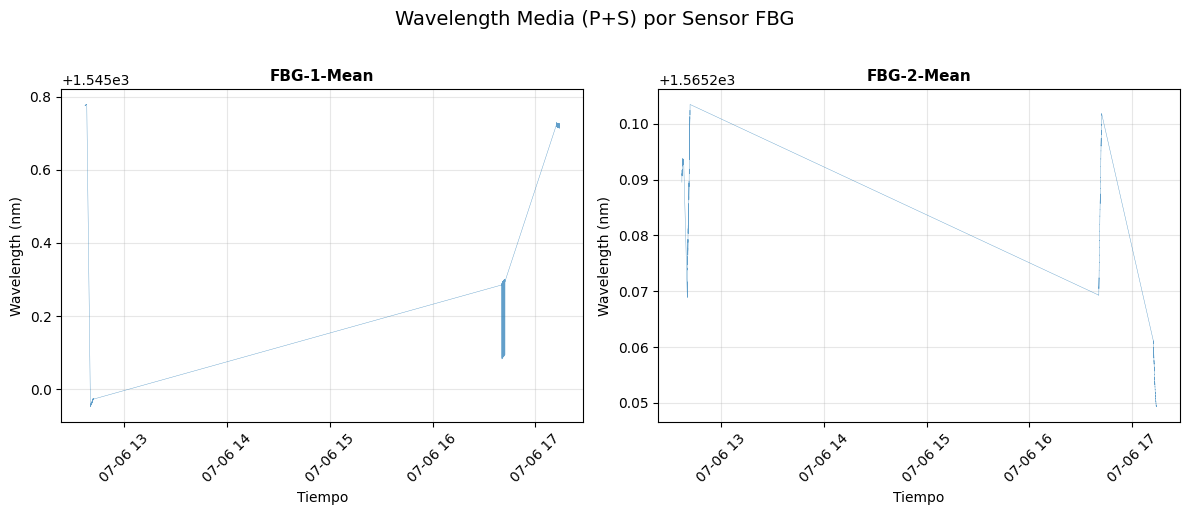

In [8]:
# Ajustar layout para N sensores activos
n_sensors = len(fbg_mean_data)

if n_sensors <= 3:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    
    ax = axes[idx]
    ax.plot(times_fbg, wav_fbg, linewidth=0.3, alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Wavelength (nm)')
    ax.set_xlabel('Tiempo')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Wavelength Media (P+S) por Sensor FBG', fontsize=14, y=1.02)
plt.tight_layout()


## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

En este setup, **solo RTD-7 (índice 7)** está en la cápsula de la fibra.


In [9]:
# ======================================================================
# INSPECCIÓN DEL ESPECTRO: ¿Cuántos picos FBG se ven?
# ======================================================================
# En 20260202, la fibra DW-3 tenía 4 canales configurados pero solo 3 funcionales.
# El 5º FBG estaba al límite del rango del interrogador.
# Ahora con la fibra suelta (sin PTFE, sin peso), ¿se ven los mismos picos?

print("="*70)
print("🔍 INSPECCIÓN DEL ESPECTRO FBG")
print("="*70)

# Mostrar rango de wavelength por sensor/canal
n_total_sensors = wav_raw.shape[2] if len(wav_raw.shape) == 3 else 1
print(f"\n📊 Canales totales en el archivo: {n_total_sensors}")
print(f"   Sensores activos detectados: {active_sensors}")

# Para cada sensor, mostrar estadísticas
for i in range(n_total_sensors):
    sensor_num = i + 1
    print(f"\n--- Sensor FBG-{sensor_num} (índice {i}) ---")
    for pol_idx, pol_name in enumerate(['P', 'S']):
        wav_data = wav_raw[:, pol_idx, i]
        mask_pos = wav_data > 0
        n_valid = mask_pos.sum()
        if n_valid > 0:
            print(f"   {pol_name}: {n_valid} puntos válidos, "
                  f"rango [{wav_data[mask_pos].min():.3f}, {wav_data[mask_pos].max():.3f}] nm, "
                  f"media={wav_data[mask_pos].mean():.3f} nm")
        else:
            print(f"   {pol_name}: ❌ SIN DATOS VÁLIDOS")

print(f"\n📌 CONCLUSIÓN:")
if len(active_sensors) == n_total_sensors:
    print(f"   ✅ Todos los {n_total_sensors} sensores tienen datos válidos.")
    if n_total_sensors >= 5:
        print(f"   → Se ven los 5 picos esperados en el espectro.")
    elif n_total_sensors == 4:
        print(f"   → Se ven 4 picos. El 5º FBG sigue sin ser visible.")
    else:
        print(f"   → Se ven solo {n_total_sensors} picos.")
else:
    omitted = [i+1 for i in range(n_total_sensors) if (i+1) not in active_sensors]
    print(f"   ⚠️  Solo {len(active_sensors)} de {n_total_sensors} sensores son funcionales.")
    print(f"   Sensores sin datos: {omitted}")


🔍 INSPECCIÓN DEL ESPECTRO FBG

📊 Canales totales en el archivo: 2
   Sensores activos detectados: [1, 2]

--- Sensor FBG-1 (índice 0) ---
   P: 45624 puntos válidos, rango [1544.879, 1545.779] nm, media=1545.403 nm
   S: 45625 puntos válidos, rango [1544.938, 1545.779] nm, media=1545.405 nm

--- Sensor FBG-2 (índice 1) ---
   P: 45624 puntos válidos, rango [1565.249, 1565.304] nm, media=1565.279 nm
   S: 45625 puntos válidos, rango [1565.249, 1565.303] nm, media=1565.279 nm

📌 CONCLUSIÓN:
   ✅ Todos los 2 sensores tienen datos válidos.
   → Se ven solo 2 picos.


### 6.2 Visualización de Perfiles (para definir plateaus)



### 6.3 Definición Manual de Plateaus



### 6.4 Calcular Sensibilidad por Plateaus



✅ Espectro cargado: TTree 'spectrum;5'
   Shape spectrum wav: (180, 2, 1, 39200)


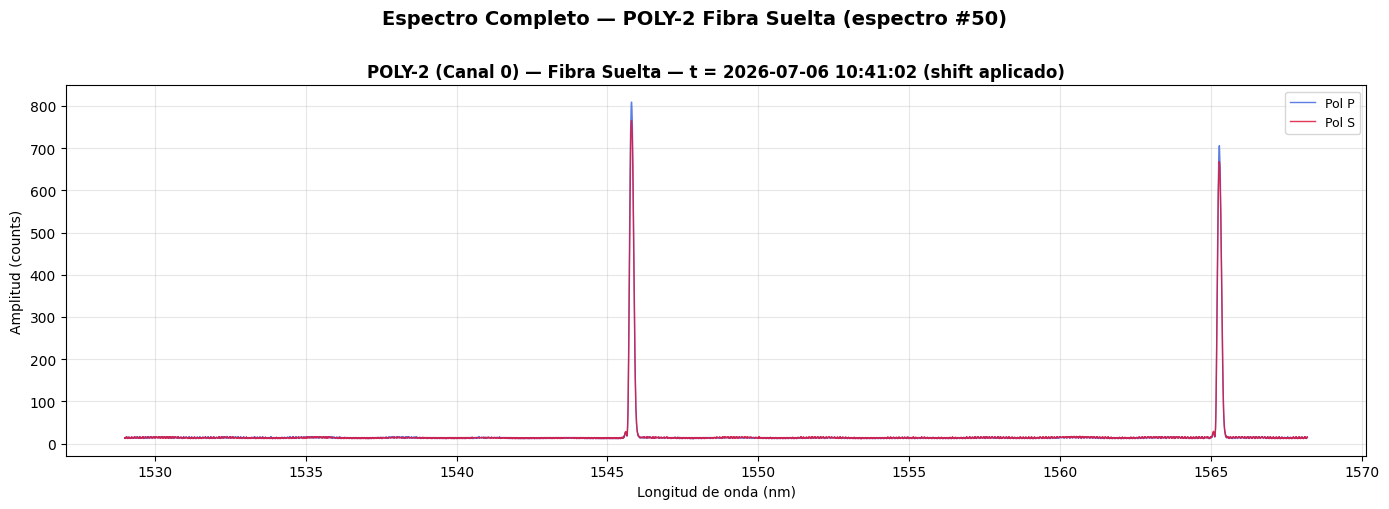


📊 ANÁLISIS PRELIMINAR DEL ESPECTRO DW-3 (espectro #50 — t = 2026-07-06 10:41:02)
   Resolución del eje λ: Δλ = 1.00 pm/punto (39200 puntos en 39.2 nm)

  ── POLY-2 (Fibra Suelta) ──────────────────────────────────────────────────
  Picos detectados: Pol P = 2, Pol S = 2
  Amplitudes Pol P:
    FBG-1: λ = 1545.798 nm,  Amp = 809 counts
    FBG-2: λ = 1565.283 nm,  Amp = 706 counts
  Rango amplitudes: 706 – 809 counts (ratio max/min = 1.15×)
  Espaciado entre sensores:
    FBG-1 → FBG-2: Δλ = 19.484 nm
  Espaciado medio: 19.484 ± 0.000 nm


In [10]:
# ══════════════════════════════════════════════════════════════════════
# ESPECTRO COMPLETO: Fibra DW-3 (fibra suelta)
# ══════════════════════════════════════════════════════════════════════
# Carga el TTree "spectrum" del archivo ROOT y muestra el espectro
# completo de la fibra DW-3 para ambas polarizaciones (P y S).
# ══════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks

# ── 1. Cargar datos de espectro desde el archivo ROOT ──
try:
    with uproot.open(filepath) as file_spec:
        # Buscar el TTree "spectrum" (puede tener ciclos ;1, ;2, etc.)
        spec_keys = [k for k in file_spec.keys() if k.split(";")[0] == "spectrum"]
        if not spec_keys:
            raise KeyError("No se encontró el TTree 'spectrum' en el archivo")
        key_spectrum = sorted(spec_keys, key=lambda k: int(k.split(";")[1]))[-1]
        data_spectrum = file_spec[key_spectrum].arrays(library="np")
        print(f"✅ Espectro cargado: TTree '{key_spectrum}'")
        print(f"   Shape spectrum wav: {data_spectrum['wav'].shape}")
except KeyError as e:
    data_spectrum = None
    print(f"⚠️  {e}")
    print("   Este archivo ROOT no contiene datos de espectro.")
except Exception as e:
    data_spectrum = None
    print(f"❌ Error al cargar espectro: {e}")

# ── 2. Visualización del espectro de DW-3 ──
if data_spectrum is not None:
    spectrum_wav = data_spectrum['wav']
    spectrum_t   = data_spectrum['t']

    n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape
    idx_espectro = min(50, n_espectros - 1)

    # ── Constantes de conversión idx → λ (FAZT I4G-16) ──
    _lam_start = 1529.0   # nm
    _lam_end   = 1568.2   # nm
    _dlam      = (_lam_end - _lam_start) / (n_puntos - 1)   # nm/pt
    wavelength_axis = np.linspace(_lam_start, _lam_end, n_puntos)

    # Canal de DW-3 (canal 0 en este setup de fibra única o canal 0 de 3-fibras)
    ch_dw3 = 0
    pol_labels = ['Pol P', 'Pol S']
    pol_colors = ['royalblue', 'crimson']

    # ── Plot del espectro ──
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    for idx_pol in range(n_pol):
        signal = spectrum_wav[idx_espectro, idx_pol, ch_dw3, :]
        ax.plot(wavelength_axis, signal, label=pol_labels[idx_pol],
                linewidth=1.0, alpha=0.85, color=pol_colors[idx_pol])

    # Convertir timestamp a string legible y aplicar TIME_SHIFT
    t_val = spectrum_t[idx_espectro, 0]
    t_dt = datetime.datetime.fromtimestamp(float(t_val), tz=TZ_VALENCIA).replace(tzinfo=None)
    t_dt_shifted = t_dt + TIME_SHIFT
    t_str = t_dt_shifted.strftime("%Y-%m-%d %H:%M:%S")

    ax.set_title(f'POLY-2 (Canal {ch_dw3}) — Fibra Suelta — t = {t_str} (shift aplicado)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitud de onda (nm)', fontsize=10)
    ax.set_ylabel('Amplitud (counts)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    plt.suptitle(f'Espectro Completo — POLY-2 Fibra Suelta (espectro #{idx_espectro})',
                 fontsize=14, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ══════════════════════════════════════════════════════════════════
    # ANÁLISIS PRELIMINAR: Amplitudes y Espaciado
    # ══════════════════════════════════════════════════════════════════
    print(f"\n{''.join(['=']*90)}")
    print(f"📊 ANÁLISIS PRELIMINAR DEL ESPECTRO DW-3 (espectro #{idx_espectro} — t = {t_str})")
    print(f"{''.join(['=']*90)}")
    print(f"   Resolución del eje λ: Δλ = {_dlam*1e3:.2f} pm/punto ({n_puntos} puntos en {_lam_end-_lam_start:.1f} nm)")

    sig_p = spectrum_wav[idx_espectro, 0, ch_dw3, :]
    sig_s = spectrum_wav[idx_espectro, 1, ch_dw3, :]

    # Detección rápida de picos
    sig_max = max(sig_p.max(), sig_s.max())
    peaks_p, _ = find_peaks(sig_p, prominence=sig_max * 0.10, distance=50,
                            height=sig_max * 0.05)
    peaks_s, _ = find_peaks(sig_s, prominence=sig_max * 0.10, distance=50,
                            height=sig_max * 0.05)

    print(f"\n  ── POLY-2 (Fibra Suelta) {''.join(['─']*50)}")
    print(f"  Picos detectados: Pol P = {len(peaks_p)}, Pol S = {len(peaks_s)}")

    # Amplitudes de picos (Pol P como referencia)
    if len(peaks_p) > 0:
        amps = sig_p[peaks_p]
        lams = wavelength_axis[peaks_p]
        amp_max, amp_min = amps.max(), amps.min()
        amp_ratio = amp_max / amp_min if amp_min > 0 else np.inf

        print(f"  Amplitudes Pol P:")
        for j, (pk, amp, lam) in enumerate(zip(peaks_p, amps, lams)):
            print(f"    FBG-{j+1}: λ = {lam:.3f} nm,  Amp = {amp:.0f} counts")
        print(f"  Rango amplitudes: {amp_min:.0f} – {amp_max:.0f} counts "
              f"(ratio max/min = {amp_ratio:.2f}×)")

        # Espaciado entre sensores consecutivos
        if len(peaks_p) > 1:
            deltas = np.diff(lams)
            print(f"  Espaciado entre sensores:")
            for j in range(len(deltas)):
                print(f"    FBG-{j+1} → FBG-{j+2}: Δλ = {deltas[j]:.3f} nm")
            print(f"  Espaciado medio: {np.mean(deltas):.3f} ± {np.std(deltas):.3f} nm")


📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (POLY-2, 06/07/2026)

✅ Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

📊 Estructura de datos:
   't': shape=(1, 2), dtype=float64
   'wav': shape=(1, 2, 1, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (1, 2, 1, 39200)
      → Dimensiones: (n_entries=1, dim1=2, dim2=1, n_points=39200)

   ⏰ Timestamps ('t'):
      Shape: (1, 2)
      Primeros valores: [1.78332703e+09 1.78332703e+09]

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   ✅ Usando timestamps de 'spectrum.t'
   Timestamps shape: (180, 2) → usando columna 0
   Tiempo objetivo:     2026-07-06 10:37:00
   Tiempo más cercano:  2026-07-06 10:37:13
   Diferencia:          13.6 segundos
   Índice del evento:   0

📊 Datos cargados del tree 'spectrum':
   Shape raw: (1, 2, 1, 39200)
   → Estructura 4D detectada, extrayendo primera entrada: (2, 1, 39200)

📊 Datos del evento listo para procesar:
   Shape final: (2, 1, 39200)
   Tamaño total

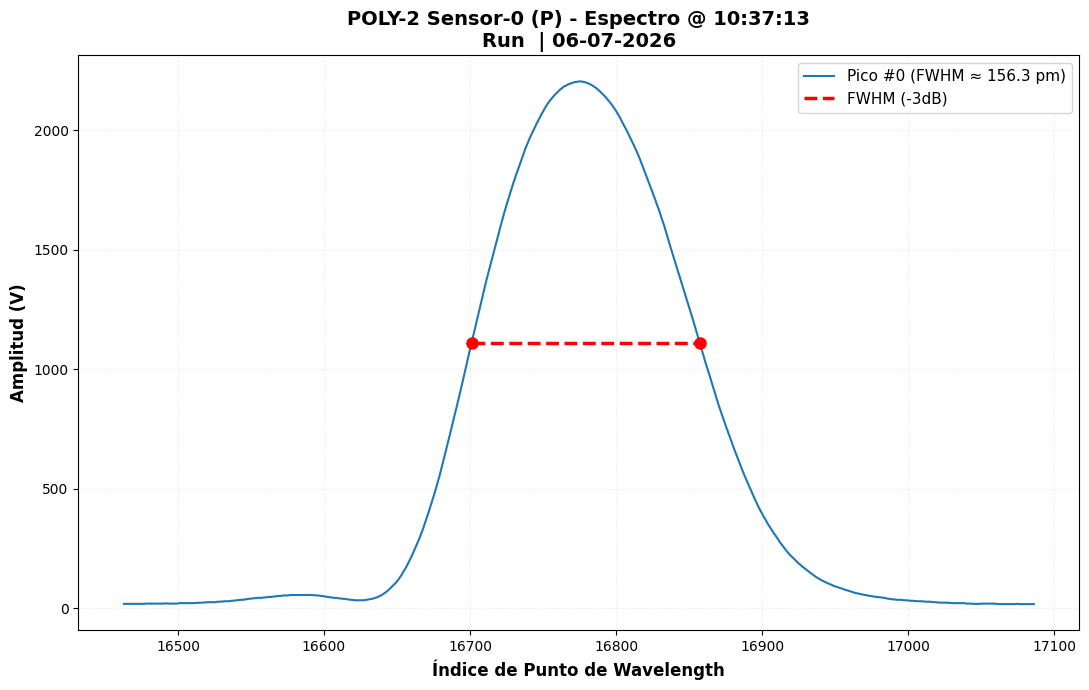


✅ Plot generado exitosamente


In [11]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 7, 6, 10, 37, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0    # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (POLY-2, 06/07/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"POLY-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        # Extraer valores escalares (results_half retorna arrays, tomamos primer elemento)
        fwhm_height = results_half[1][0] if hasattr(results_half[1], '__len__') else results_half[1]
        fwhm_left = results_half[2][0] if hasattr(results_half[2], '__len__') else results_half[2]
        fwhm_right = results_half[3][0] if hasattr(results_half[3], '__len__') else results_half[3]
        
        plt.hlines(fwhm_height, fwhm_left, fwhm_right, 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([fwhm_left, fwhm_right], [fwhm_height, fwhm_height], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\nRun  | 06-07-2026", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\nRun  | 06-07-2026", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")


🔍 PROCESANDO TIEMPO: 10:37:00
   Tiempo más cercano encontrado: 10:37:13
   ✅ Pico en pos 16775 | Dinámica: 21.39 dB | FWHM: 267.5 pm

🔍 PROCESANDO TIEMPO: 10:41:00
   Tiempo más cercano encontrado: 10:41:00
   ✅ Pico en pos 16798 | Dinámica: 18.28 dB | FWHM: 251.3 pm


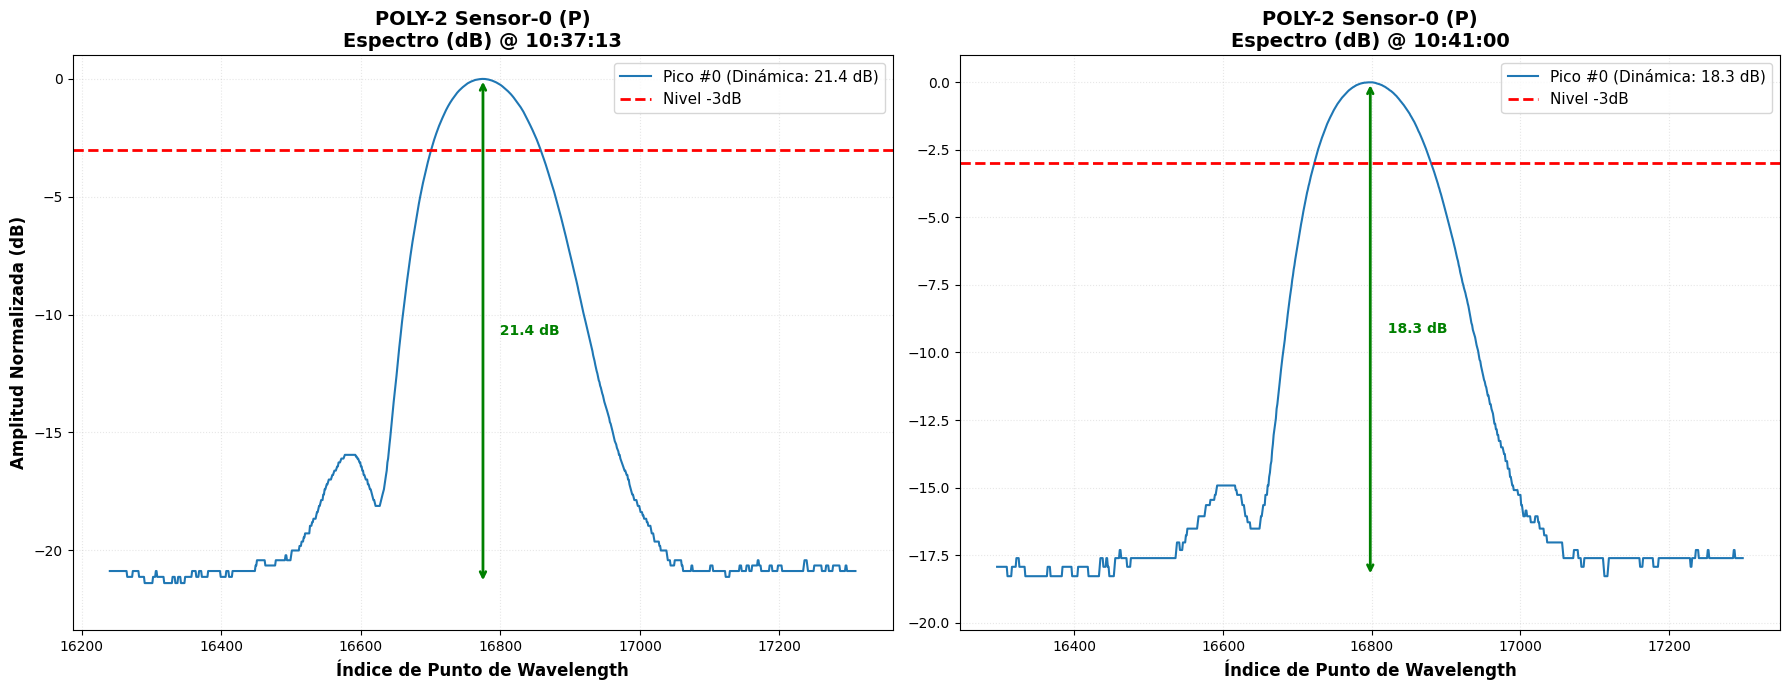

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS
# ============================================================================

# ⏰ Tiempos a visualizar (Izquierda y Derecha)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 10, 37, 0),
    datetime.datetime(2026, 7, 6, 10, 41, 0)
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida en tu entorno
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]
FIBER_NAME = f"POLY-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO (Para reusar en ambos subplots)
# ============================================================================

def analyze_and_plot(file, target_time, ax):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO TIEMPO: {target_time.strftime('%H:%M:%S')}")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        print(f"   Tiempo más cercano encontrado: {closest_time.strftime('%H:%M:%S')}")
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax.text(0.5, 0.5, f"Error cargando datos:\n{e}", ha='center', va='center', transform=ax.transAxes)
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        ax.text(0.5, 0.5, f"Error extrayendo espectro:\n{e}", ha='center', va='center', transform=ax.transAxes)
        return

    # --- PASO 3: Análisis dB, FWHM y Amplitud ---
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        results_half = peak_widths(spectrum_db, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    y_db = spectrum_db[start_idx:end_idx]
    
    base_level = np.min(y_db)
    peak_level = np.max(y_db) 
    amplitude_diff = peak_level - base_level
    
    print(f"   ✅ Pico en pos {center_idx} | Dinámica: {amplitude_diff:.2f} dB | FWHM: {fwhm_points:.1f} pm")

    # --- PASO 4: Dibujar en el Subplot ('ax') ---
    ax.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (Dinámica: {amplitude_diff:.1f} dB)", color='#1f77b4')
    ax.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    ax.annotate('', xy=(center_idx, peak_level), xytext=(center_idx, base_level),
                 arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax.text(center_idx + 10, (peak_level + base_level) / 2, f'  {amplitude_diff:.1f} dB', 
             color='green', fontweight='bold', va='center')
    
    ax.set_xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    
    # Solo poner la etiqueta del eje Y en el primer subplot para no saturar visualmente
    if ax == fig.axes[0]:
        ax.set_ylabel("Amplitud Normalizada (dB)", fontsize=12, fontweight='bold')
        
    ax.set_title(f"{FIBER_NAME}\nEspectro (dB) @ {closest_time.strftime('%H:%M:%S')}", fontsize=14, fontweight='bold')
    
    ax.legend(fontsize=11, loc='best')
    ax.grid(alpha=0.3, linestyle=':')
    ax.set_ylim(min(y_db) - 2, 1)

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR FIGURA Y SUBPLOTS
# ============================================================================

# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            # Procesar el primer tiempo en el eje izquierdo (axes[0])
            analyze_and_plot(file, TARGET_TIMES[0], axes[0])
            
            # Procesar el segundo tiempo en el eje derecho (axes[1])
            analyze_and_plot(file, TARGET_TIMES[1], axes[1])
            
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

# Ajustar márgenes para que no se superpongan
plt.tight_layout()
plt.show()


🔍 PROCESANDO TIEMPO: 10:37:00
   Tiempo más cercano encontrado: 10:37:13
   ✅ Pico en pos 16775 | Dinámica: 20.88 dB | FWHM: 156.3 pm

🔍 PROCESANDO TIEMPO: 10:41:00
   Tiempo más cercano encontrado: 10:41:00
   ✅ Pico en pos 16798 | Dinámica: 17.93 dB | FWHM: 156.0 pm


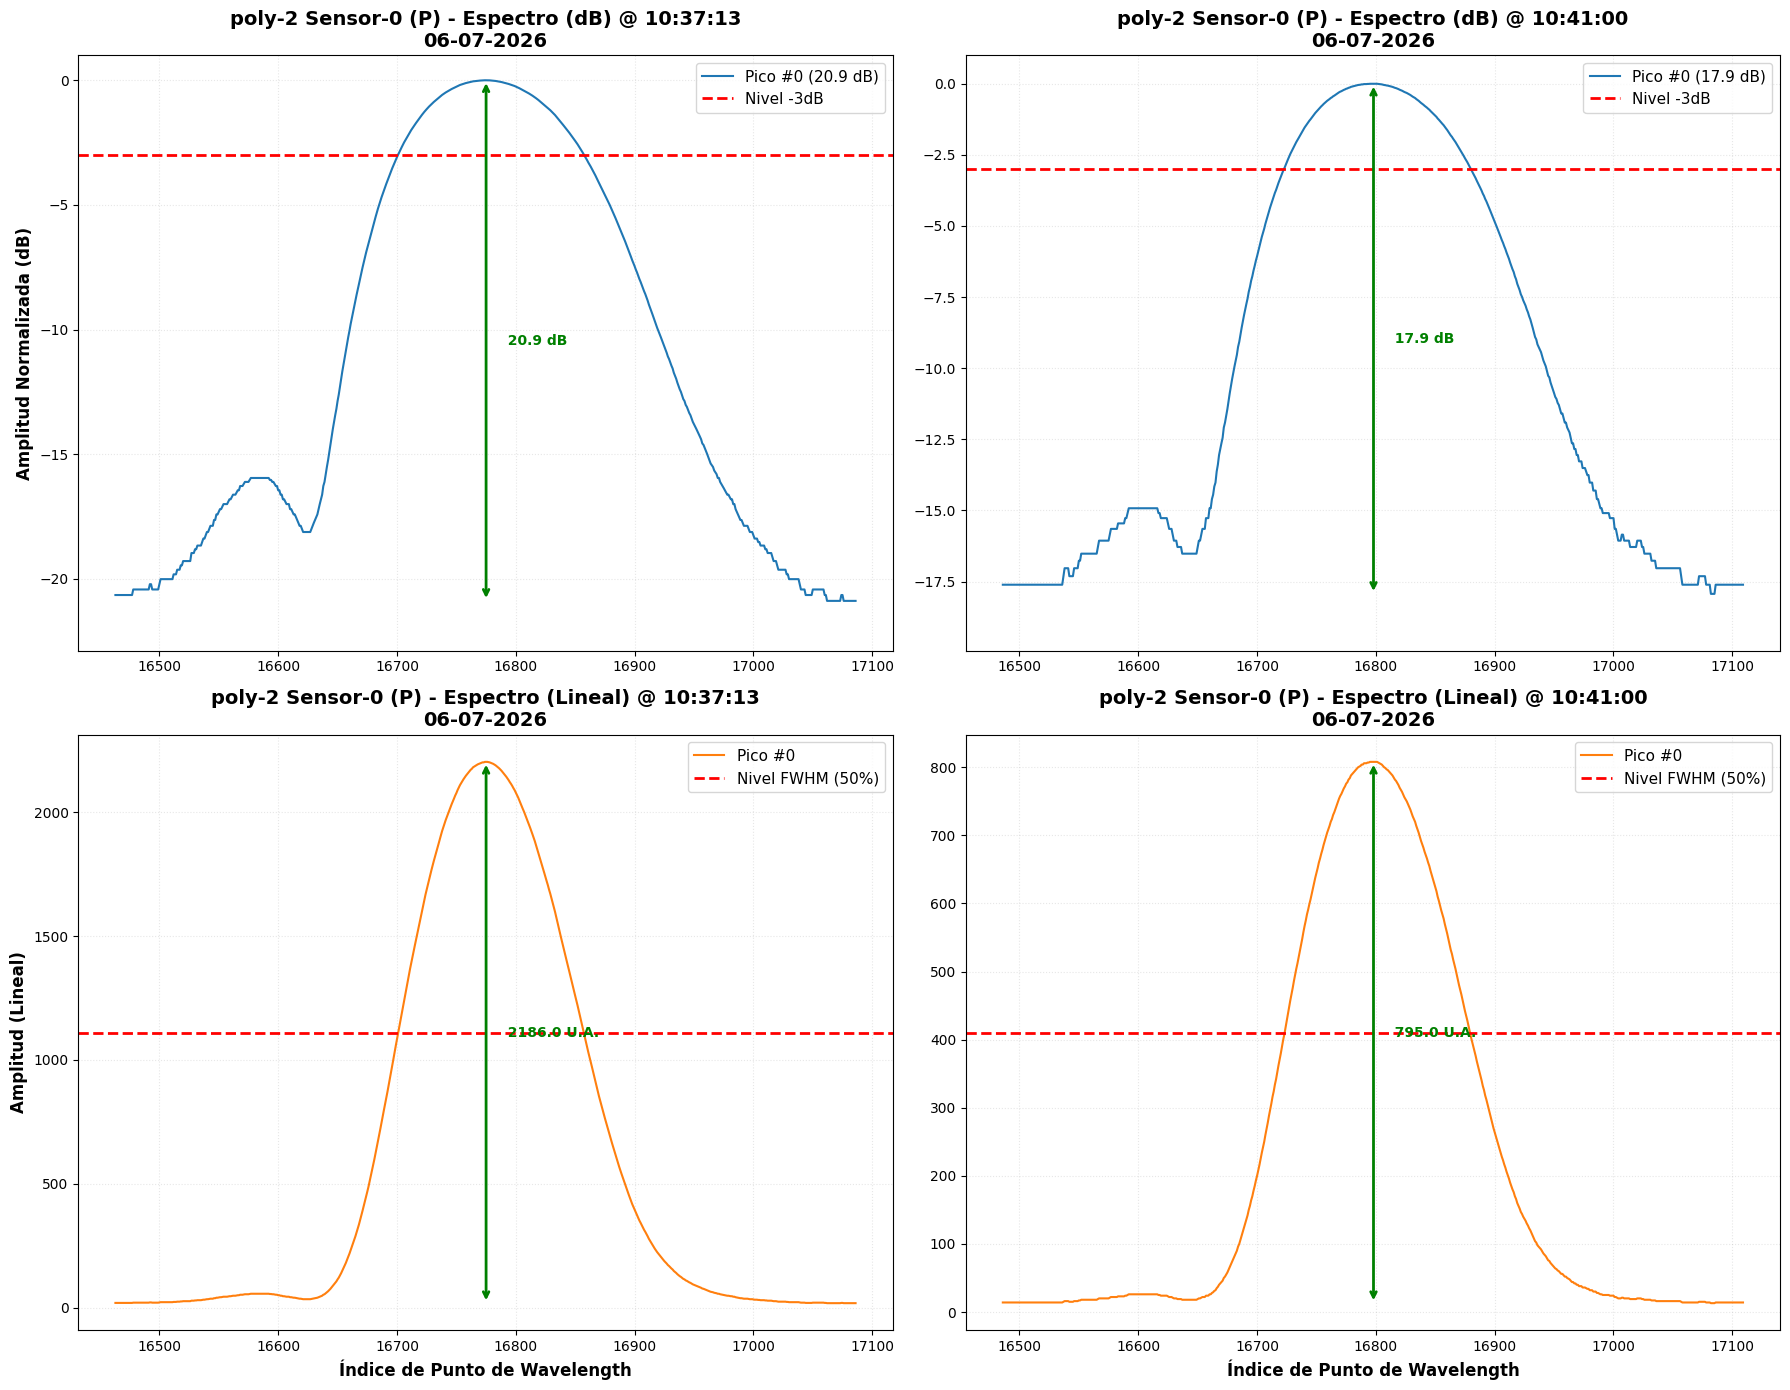

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS
# ============================================================================

# ⏰ Tiempos a visualizar (Columna Izquierda y Columna Derecha)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 10, 37, 0),
    datetime.datetime(2026, 7, 6, 10, 41, 0)
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida en tu entorno
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# Actualización solicitada: fibra poly-2 y fecha 06-07-2026
FIBER_NAME = f"poly-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
PLOT_DATE = "06-07-2026"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO (Para reusar en ambos tiempos)
# ============================================================================

def analyze_and_plot(file, target_time, ax_db, ax_lin):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO TIEMPO: {target_time.strftime('%H:%M:%S')}")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        print(f"   Tiempo más cercano encontrado: {closest_time.strftime('%H:%M:%S')}")
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax_db.text(0.5, 0.5, f"Error cargando datos:\n{e}", ha='center', va='center', transform=ax_db.transAxes)
        ax_lin.text(0.5, 0.5, f"Error cargando datos:\n{e}", ha='center', va='center', transform=ax_lin.transAxes)
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        ax_db.text(0.5, 0.5, f"Error extrayendo espectro:\n{e}", ha='center', va='center', transform=ax_db.transAxes)
        ax_lin.text(0.5, 0.5, f"Error extrayendo espectro:\n{e}", ha='center', va='center', transform=ax_lin.transAxes)
        return

    # --- PASO 3: Análisis de datos ---
    # Procesar para la escala en dB
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        # Calcular FWHM sobre la escala lineal (al 50% de la altura relativa)
        results_half = peak_widths(spectrum_full, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    # Definir ventana de visualización
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    
    # Extraer segmentos (ventana) para dB y Lineal
    y_db = spectrum_db[start_idx:end_idx]
    y_lin = spectrum_full[start_idx:end_idx]
    
    # Cálculos Dinámica en dB
    base_level_db = np.min(y_db)
    peak_level_db = np.max(y_db) 
    amplitude_diff_db = peak_level_db - base_level_db
    
    # Cálculos Amplitud en Lineal
    base_level_lin = np.min(y_lin)
    peak_level_lin = np.max(y_lin)
    amplitude_diff_lin = peak_level_lin - base_level_lin
    fwhm_level_lin = base_level_lin + (amplitude_diff_lin * 0.5) # Nivel del 50%

    print(f"   ✅ Pico en pos {center_idx} | Dinámica: {amplitude_diff_db:.2f} dB | FWHM: {fwhm_points:.1f} pm")

    # --- PASO 4a: Dibujar en el Subplot de arriba (dB) ---
    ax_db.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} ({amplitude_diff_db:.1f} dB)", color='#1f77b4')
    ax_db.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    # Flecha y texto en dB
    ax_db.annotate('', xy=(center_idx, peak_level_db), xytext=(center_idx, base_level_db),
                   arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_db.text(center_idx + 10, (peak_level_db + base_level_db) / 2, f'  {amplitude_diff_db:.1f} dB', 
               color='green', fontweight='bold', va='center')
    
    if ax_db == axes[0, 0]: # Eje Y solo a la izquierda
        ax_db.set_ylabel("Amplitud Normalizada (dB)", fontsize=12, fontweight='bold')
        
    ax_db.set_title(f"{FIBER_NAME} - Espectro (dB) @ {closest_time.strftime('%H:%M:%S')}\n{PLOT_DATE}", fontsize=14, fontweight='bold')
    ax_db.legend(fontsize=11, loc='best')
    ax_db.grid(alpha=0.3, linestyle=':')
    ax_db.set_ylim(min(y_db) - 2, 1)

    # --- PASO 4b: Dibujar en el Subplot de abajo (Lineal) ---
    ax_lin.plot(x_pm, y_lin, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX}", color='#ff7f0e')
    ax_lin.axhline(fwhm_level_lin, color='red', linestyle='--', linewidth=2, label='Nivel FWHM (50%)')
    
    # Flecha y texto en Lineal
    ax_lin.annotate('', xy=(center_idx, peak_level_lin), xytext=(center_idx, base_level_lin),
                    arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_lin.text(center_idx + 10, (peak_level_lin + base_level_lin) / 2, f'  {amplitude_diff_lin:.1f} U.A.', 
                color='green', fontweight='bold', va='center')
    
    ax_lin.set_xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    
    if ax_lin == axes[1, 0]: # Eje Y solo a la izquierda
        ax_lin.set_ylabel("Amplitud (Lineal)", fontsize=12, fontweight='bold')
        
    ax_lin.set_title(f"{FIBER_NAME} - Espectro (Lineal) @ {closest_time.strftime('%H:%M:%S')}\n{PLOT_DATE}", fontsize=14, fontweight='bold')
    ax_lin.legend(fontsize=11, loc='best')
    ax_lin.grid(alpha=0.3, linestyle=':')

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR FIGURA Y MATRIZ DE SUBPLOTS 2x2
# ============================================================================

# Crear una figura con 2 filas (dB arriba, Lineal abajo) y 2 columnas (10:37h izq, 10:41h der)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            # Procesar el primer tiempo: Columna 0 (Izquierda) -> axes[0, 0] para dB y axes[1, 0] para Lineal
            analyze_and_plot(file, TARGET_TIMES[0], ax_db=axes[0, 0], ax_lin=axes[1, 0])
            
            # Procesar el segundo tiempo: Columna 1 (Derecha) -> axes[0, 1] para dB y axes[1, 1] para Lineal
            analyze_and_plot(file, TARGET_TIMES[1], ax_db=axes[0, 1], ax_lin=axes[1, 1])
            
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

# Ajustar márgenes para que no se superpongan textos y ejes
plt.tight_layout()
plt.show()


🔍 PROCESANDO TIEMPO: 14:41:00
   Tiempo más cercano encontrado: 14:40:59
   ✅ Pico en pos 16772 | Dinámica: 20.92 dB | FWHM: 156.3 pm

🔍 PROCESANDO TIEMPO: 10:37:00
   Tiempo más cercano encontrado: 10:37:13
   ✅ Pico en pos 16775 | Dinámica: 20.88 dB | FWHM: 156.3 pm


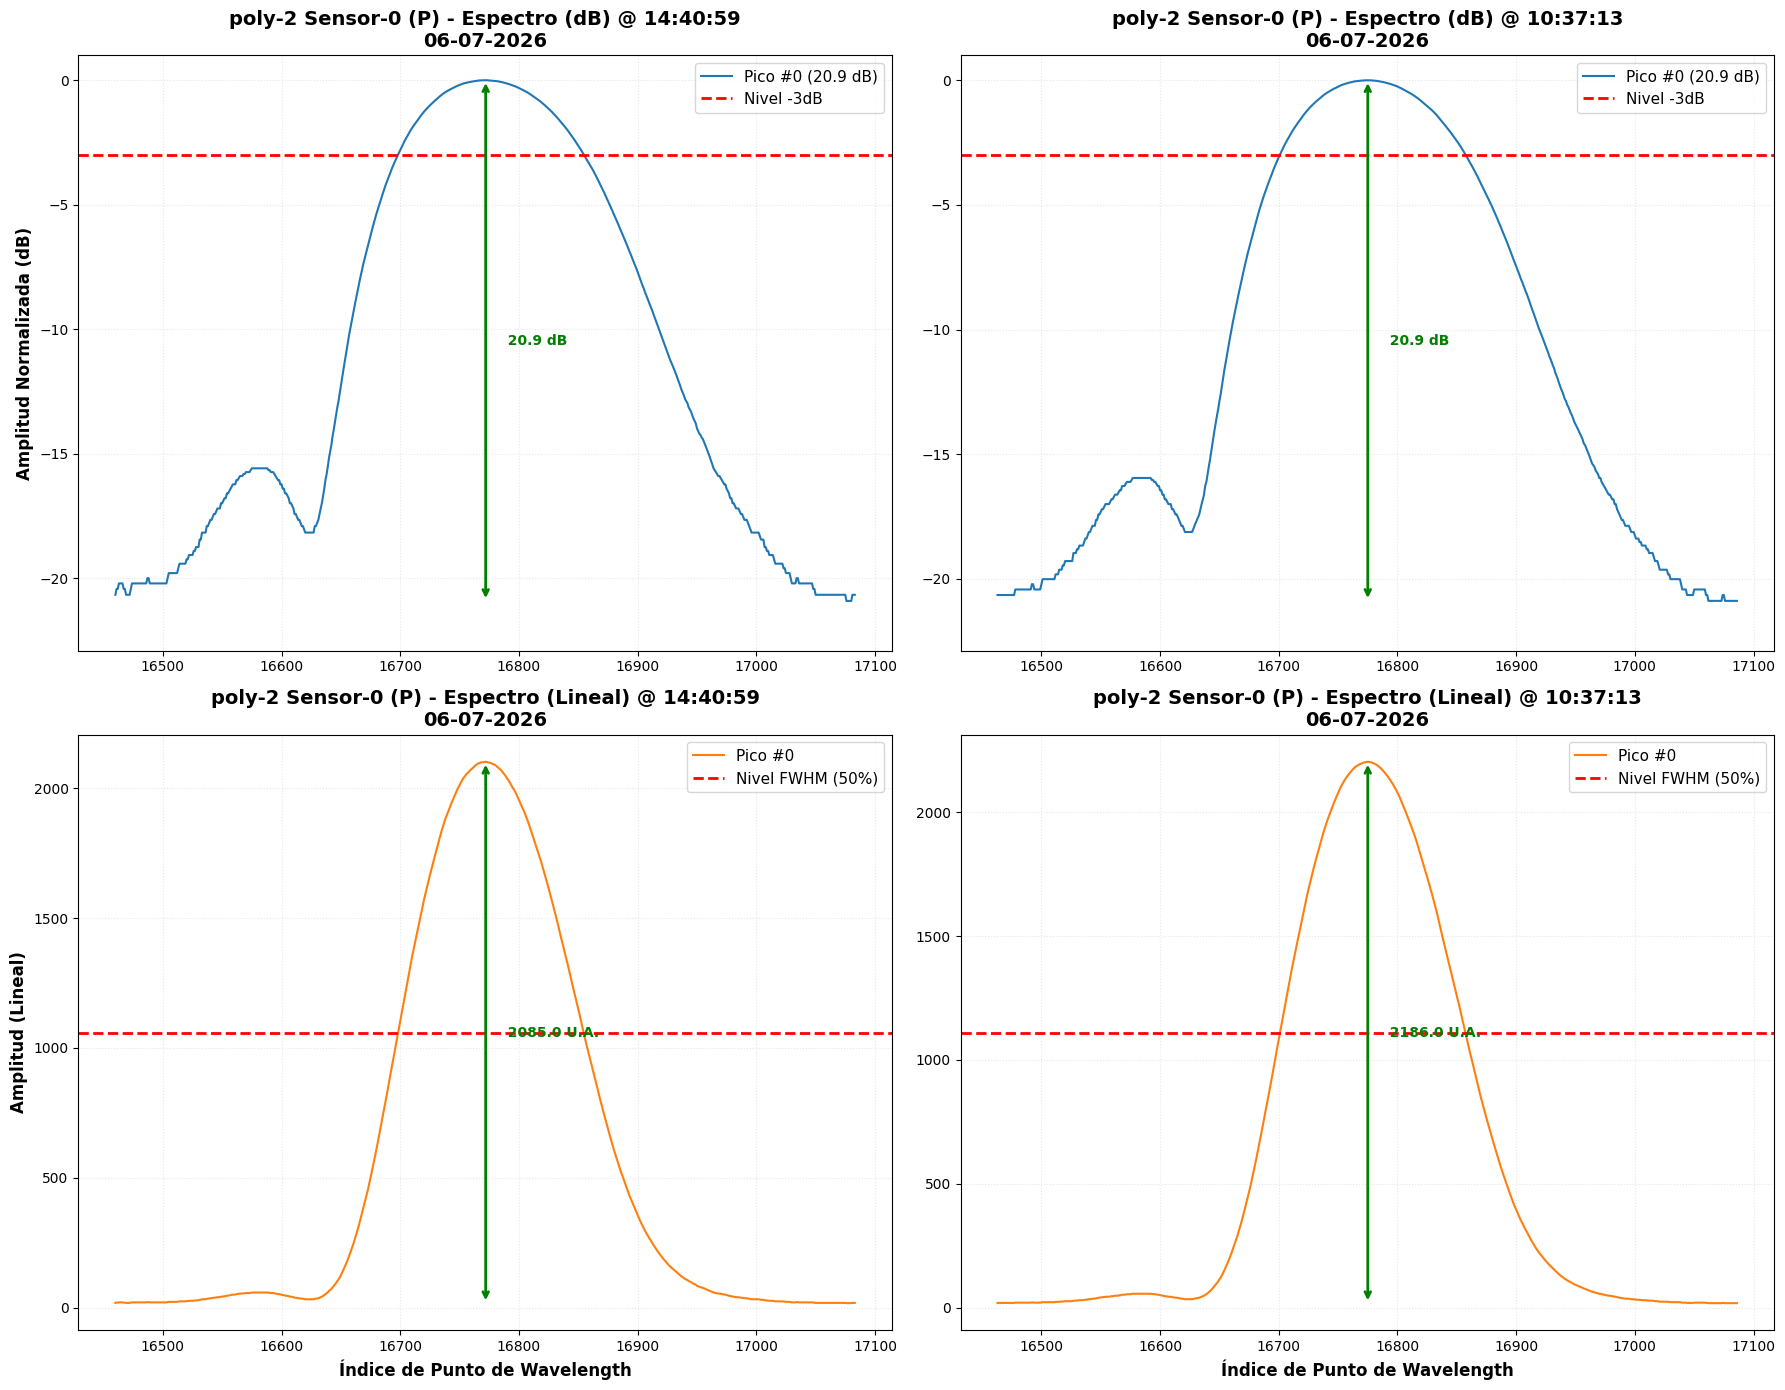

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS
# ============================================================================

# ⏰ Tiempos a visualizar (Columna Izquierda y Columna Derecha)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 14, 41, 0),
    datetime.datetime(2026, 7, 6, 10, 37, 0)
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida en tu entorno
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# Actualización solicitada: fibra poly-2 y fecha 06-07-2026
FIBER_NAME = f"poly-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
PLOT_DATE = "06-07-2026"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO (Para reusar en ambos tiempos)
# ============================================================================

def analyze_and_plot(file, target_time, ax_db, ax_lin):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO TIEMPO: {target_time.strftime('%H:%M:%S')}")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        print(f"   Tiempo más cercano encontrado: {closest_time.strftime('%H:%M:%S')}")
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax_db.text(0.5, 0.5, f"Error cargando datos:\n{e}", ha='center', va='center', transform=ax_db.transAxes)
        ax_lin.text(0.5, 0.5, f"Error cargando datos:\n{e}", ha='center', va='center', transform=ax_lin.transAxes)
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        ax_db.text(0.5, 0.5, f"Error extrayendo espectro:\n{e}", ha='center', va='center', transform=ax_db.transAxes)
        ax_lin.text(0.5, 0.5, f"Error extrayendo espectro:\n{e}", ha='center', va='center', transform=ax_lin.transAxes)
        return

    # --- PASO 3: Análisis de datos ---
    # Procesar para la escala en dB
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        # Calcular FWHM sobre la escala lineal (al 50% de la altura relativa)
        results_half = peak_widths(spectrum_full, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    # Definir ventana de visualización
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    
    # Extraer segmentos (ventana) para dB y Lineal
    y_db = spectrum_db[start_idx:end_idx]
    y_lin = spectrum_full[start_idx:end_idx]
    
    # Cálculos Dinámica en dB
    base_level_db = np.min(y_db)
    peak_level_db = np.max(y_db) 
    amplitude_diff_db = peak_level_db - base_level_db
    
    # Cálculos Amplitud en Lineal
    base_level_lin = np.min(y_lin)
    peak_level_lin = np.max(y_lin)
    amplitude_diff_lin = peak_level_lin - base_level_lin
    fwhm_level_lin = base_level_lin + (amplitude_diff_lin * 0.5) # Nivel del 50%

    print(f"   ✅ Pico en pos {center_idx} | Dinámica: {amplitude_diff_db:.2f} dB | FWHM: {fwhm_points:.1f} pm")

    # --- PASO 4a: Dibujar en el Subplot de arriba (dB) ---
    ax_db.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} ({amplitude_diff_db:.1f} dB)", color='#1f77b4')
    ax_db.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    # Flecha y texto en dB
    ax_db.annotate('', xy=(center_idx, peak_level_db), xytext=(center_idx, base_level_db),
                   arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_db.text(center_idx + 10, (peak_level_db + base_level_db) / 2, f'  {amplitude_diff_db:.1f} dB', 
               color='green', fontweight='bold', va='center')
    
    if ax_db == axes[0, 0]: # Eje Y solo a la izquierda
        ax_db.set_ylabel("Amplitud Normalizada (dB)", fontsize=12, fontweight='bold')
        
    ax_db.set_title(f"{FIBER_NAME} - Espectro (dB) @ {closest_time.strftime('%H:%M:%S')}\n{PLOT_DATE}", fontsize=14, fontweight='bold')
    ax_db.legend(fontsize=11, loc='best')
    ax_db.grid(alpha=0.3, linestyle=':')
    ax_db.set_ylim(min(y_db) - 2, 1)

    # --- PASO 4b: Dibujar en el Subplot de abajo (Lineal) ---
    ax_lin.plot(x_pm, y_lin, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX}", color='#ff7f0e')
    ax_lin.axhline(fwhm_level_lin, color='red', linestyle='--', linewidth=2, label='Nivel FWHM (50%)')
    
    # Flecha y texto en Lineal
    ax_lin.annotate('', xy=(center_idx, peak_level_lin), xytext=(center_idx, base_level_lin),
                    arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_lin.text(center_idx + 10, (peak_level_lin + base_level_lin) / 2, f'  {amplitude_diff_lin:.1f} U.A.', 
                color='green', fontweight='bold', va='center')
    
    ax_lin.set_xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    
    if ax_lin == axes[1, 0]: # Eje Y solo a la izquierda
        ax_lin.set_ylabel("Amplitud (Lineal)", fontsize=12, fontweight='bold')
        
    ax_lin.set_title(f"{FIBER_NAME} - Espectro (Lineal) @ {closest_time.strftime('%H:%M:%S')}\n{PLOT_DATE}", fontsize=14, fontweight='bold')
    ax_lin.legend(fontsize=11, loc='best')
    ax_lin.grid(alpha=0.3, linestyle=':')

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR FIGURA Y MATRIZ DE SUBPLOTS 2x2
# ============================================================================

# Crear una figura con 2 filas (dB arriba, Lineal abajo) y 2 columnas (10:37h izq, 10:41h der)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            # Procesar el primer tiempo: Columna 0 (Izquierda) -> axes[0, 0] para dB y axes[1, 0] para Lineal
            analyze_and_plot(file, TARGET_TIMES[0], ax_db=axes[0, 0], ax_lin=axes[1, 0])
            
            # Procesar el segundo tiempo: Columna 1 (Derecha) -> axes[0, 1] para dB y axes[1, 1] para Lineal
            analyze_and_plot(file, TARGET_TIMES[1], ax_db=axes[0, 1], ax_lin=axes[1, 1])
            
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

# Ajustar márgenes para que no se superpongan textos y ejes
plt.tight_layout()
plt.show()


🔍 PROCESANDO TIEMPO: 10:37:00
   Tiempo más cercano: 10:37:13
   ✅ Pico en pos 16775 | Dinámica: 21.39 dB | FWHM: 156.3 pm

🔍 PROCESANDO TIEMPO: 10:41:00
   Tiempo más cercano: 10:41:00
   ✅ Pico en pos 16798 | Dinámica: 18.28 dB | FWHM: 156.0 pm

🔍 PROCESANDO TIEMPO: 16:41:00
   Tiempo más cercano: 15:14:01
   ✅ Pico en pos 16761 | Dinámica: 19.84 dB | FWHM: 156.9 pm


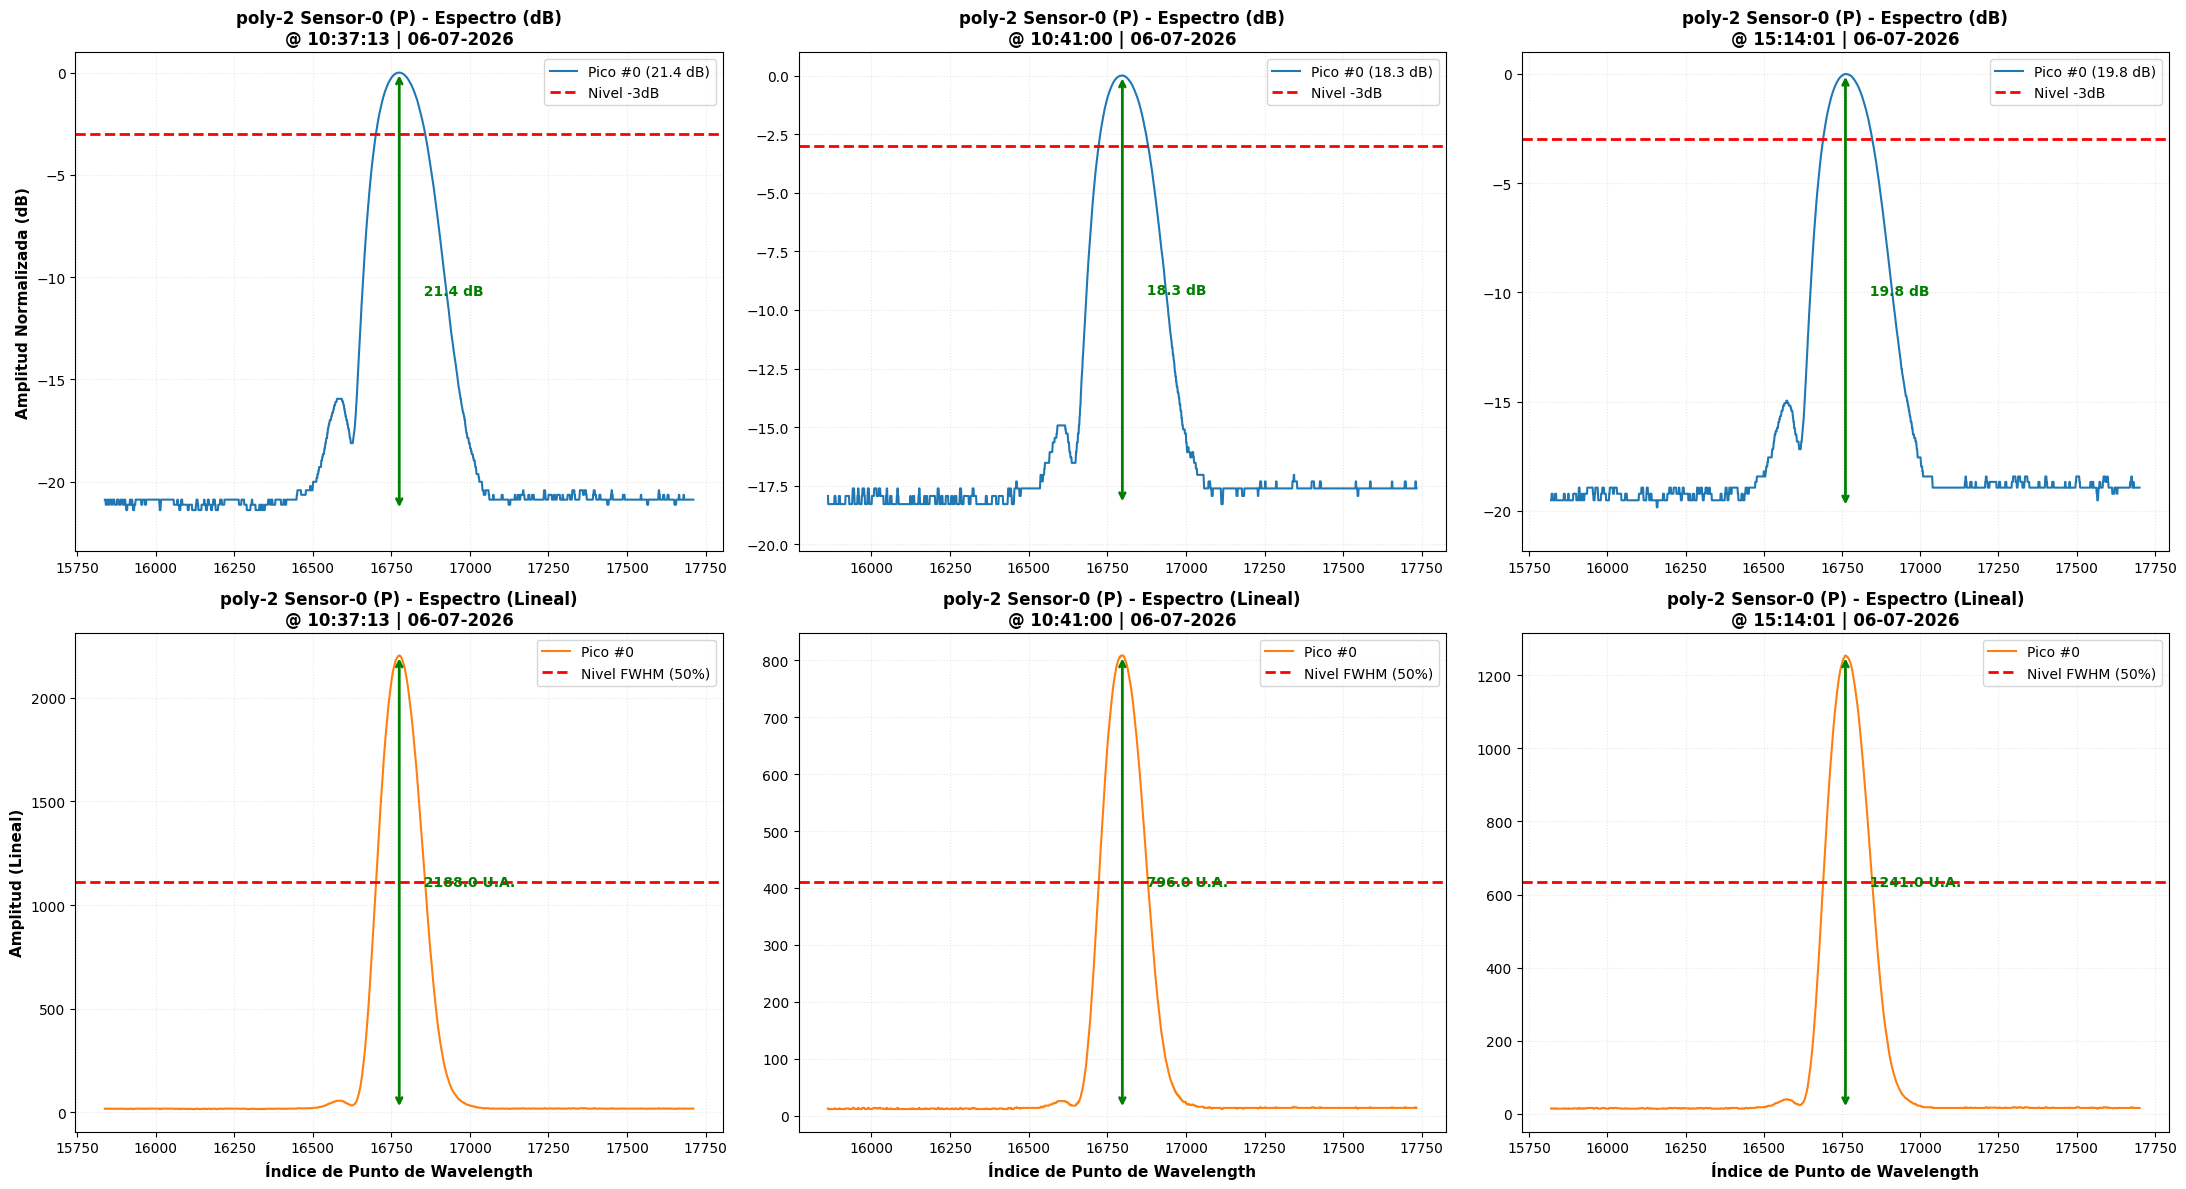

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS (3 TIEMPOS)
# ============================================================================

# ⏰ Tiempos a visualizar (Columnas 1, 2 y 3)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 10, 37, 0),
    datetime.datetime(2026, 7, 6, 10, 41, 0),
    datetime.datetime(2026, 7, 6, 16, 41, 0)
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida en tu entorno
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# Nomenclatura
FIBER_NAME = f"poly-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
PLOT_DATE = "06-07-2026"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO
# ============================================================================

def analyze_and_plot(file, target_time, ax_db, ax_lin):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO TIEMPO: {target_time.strftime('%H:%M:%S')}")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        print(f"   Tiempo más cercano: {closest_time.strftime('%H:%M:%S')}")
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax_db.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        ax_lin.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        return

    # --- PASO 3: Análisis de datos (Cálculo robusto del fondo) ---
    # Procesar la conversión a dB
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        # Calcular FWHM sobre la escala lineal de manera rigurosa
        results_half = peak_widths(spectrum_full, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    # Ampliar la ventana significativamente para garantizar que tocamos el ruido base
    window = max(int(fwhm_points * 6), 150) 
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    
    # Extraer segmentos (ventana) para dB y Lineal
    y_db = spectrum_db[start_idx:end_idx]
    y_lin = spectrum_full[start_idx:end_idx]
    
    # Cálculos Dinámica en dB (ahora sí compara contra el fondo real)
    base_level_db = np.min(y_db)
    peak_level_db = np.max(y_db) 
    amplitude_diff_db = peak_level_db - base_level_db
    
    # Cálculos Amplitud en Lineal
    base_level_lin = np.min(y_lin)
    peak_level_lin = np.max(y_lin)
    amplitude_diff_lin = peak_level_lin - base_level_lin
    fwhm_level_lin = base_level_lin + (amplitude_diff_lin * 0.5)

    print(f"   ✅ Pico en pos {center_idx} | Dinámica: {amplitude_diff_db:.2f} dB | FWHM: {fwhm_points:.1f} pm")

    # --- PASO 4a: Dibujar en dB (Fila Superior) ---
    ax_db.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} ({amplitude_diff_db:.1f} dB)", color='#1f77b4')
    ax_db.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    ax_db.annotate('', xy=(center_idx, peak_level_db), xytext=(center_idx, base_level_db),
                   arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_db.text(center_idx + (window*0.05), (peak_level_db + base_level_db) / 2, f'  {amplitude_diff_db:.1f} dB', 
               color='green', fontweight='bold', va='center')
    
    # Etiquetas de ejes (Solo a la izquierda para mantener la matriz limpia)
    if ax_db.get_subplotspec().colspan.start == 0:
        ax_db.set_ylabel("Amplitud Normalizada (dB)", fontsize=11, fontweight='bold')
        
    ax_db.set_title(f"{FIBER_NAME} - Espectro (dB)\n@ {closest_time.strftime('%H:%M:%S')} | {PLOT_DATE}", fontsize=12, fontweight='bold')
    ax_db.legend(fontsize=10, loc='best')
    ax_db.grid(alpha=0.3, linestyle=':')
    ax_db.set_ylim(min(y_db) - 2, 1)

    # --- PASO 4b: Dibujar en Lineal (Fila Inferior) ---
    ax_lin.plot(x_pm, y_lin, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX}", color='#ff7f0e')
    ax_lin.axhline(fwhm_level_lin, color='red', linestyle='--', linewidth=2, label='Nivel FWHM (50%)')
    
    ax_lin.annotate('', xy=(center_idx, peak_level_lin), xytext=(center_idx, base_level_lin),
                    arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_lin.text(center_idx + (window*0.05), (peak_level_lin + base_level_lin) / 2, f'  {amplitude_diff_lin:.1f} U.A.', 
                color='green', fontweight='bold', va='center')
    
    ax_lin.set_xlabel("Índice de Punto de Wavelength", fontsize=11, fontweight='bold')
    
    # Etiquetas de ejes
    if ax_lin.get_subplotspec().colspan.start == 0:
        ax_lin.set_ylabel("Amplitud (Lineal)", fontsize=11, fontweight='bold')
        
    ax_lin.set_title(f"{FIBER_NAME} - Espectro (Lineal)\n@ {closest_time.strftime('%H:%M:%S')} | {PLOT_DATE}", fontsize=12, fontweight='bold')
    ax_lin.legend(fontsize=10, loc='best')
    ax_lin.grid(alpha=0.3, linestyle=':')

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR MATRIZ DE SUBPLOTS 2x3
# ============================================================================

# Crear figura ancha para alojar 3 columnas cómodamente
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            # Iterar sobre los 3 tiempos y asignar a las columnas 0, 1 y 2
            for col_idx, target_t in enumerate(TARGET_TIMES):
                analyze_and_plot(file, target_t, ax_db=axes[0, col_idx], ax_lin=axes[1, col_idx])
                
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

# Ajustar márgenes
plt.tight_layout()
plt.show()


🔍 PROCESANDO TIEMPO BUSCADO: 10:37:00 (UTC)
   Tiempo más cercano encontrado: 10:37:13
   ✅ Pico en pos 16775 | Dinámica: 21.39 dB

🔍 PROCESANDO TIEMPO BUSCADO: 10:41:00 (UTC)
   Tiempo más cercano encontrado: 10:41:00
   ✅ Pico en pos 16798 | Dinámica: 18.28 dB

🔍 PROCESANDO TIEMPO BUSCADO: 14:41:00 (UTC)
   Tiempo más cercano encontrado: 14:40:59
   ✅ Pico en pos 16772 | Dinámica: 21.47 dB

🔍 PROCESANDO TIEMPO BUSCADO: 15:13:00 (UTC)
   Tiempo más cercano encontrado: 15:13:00
   ✅ Pico en pos 16764 | Dinámica: 20.19 dB


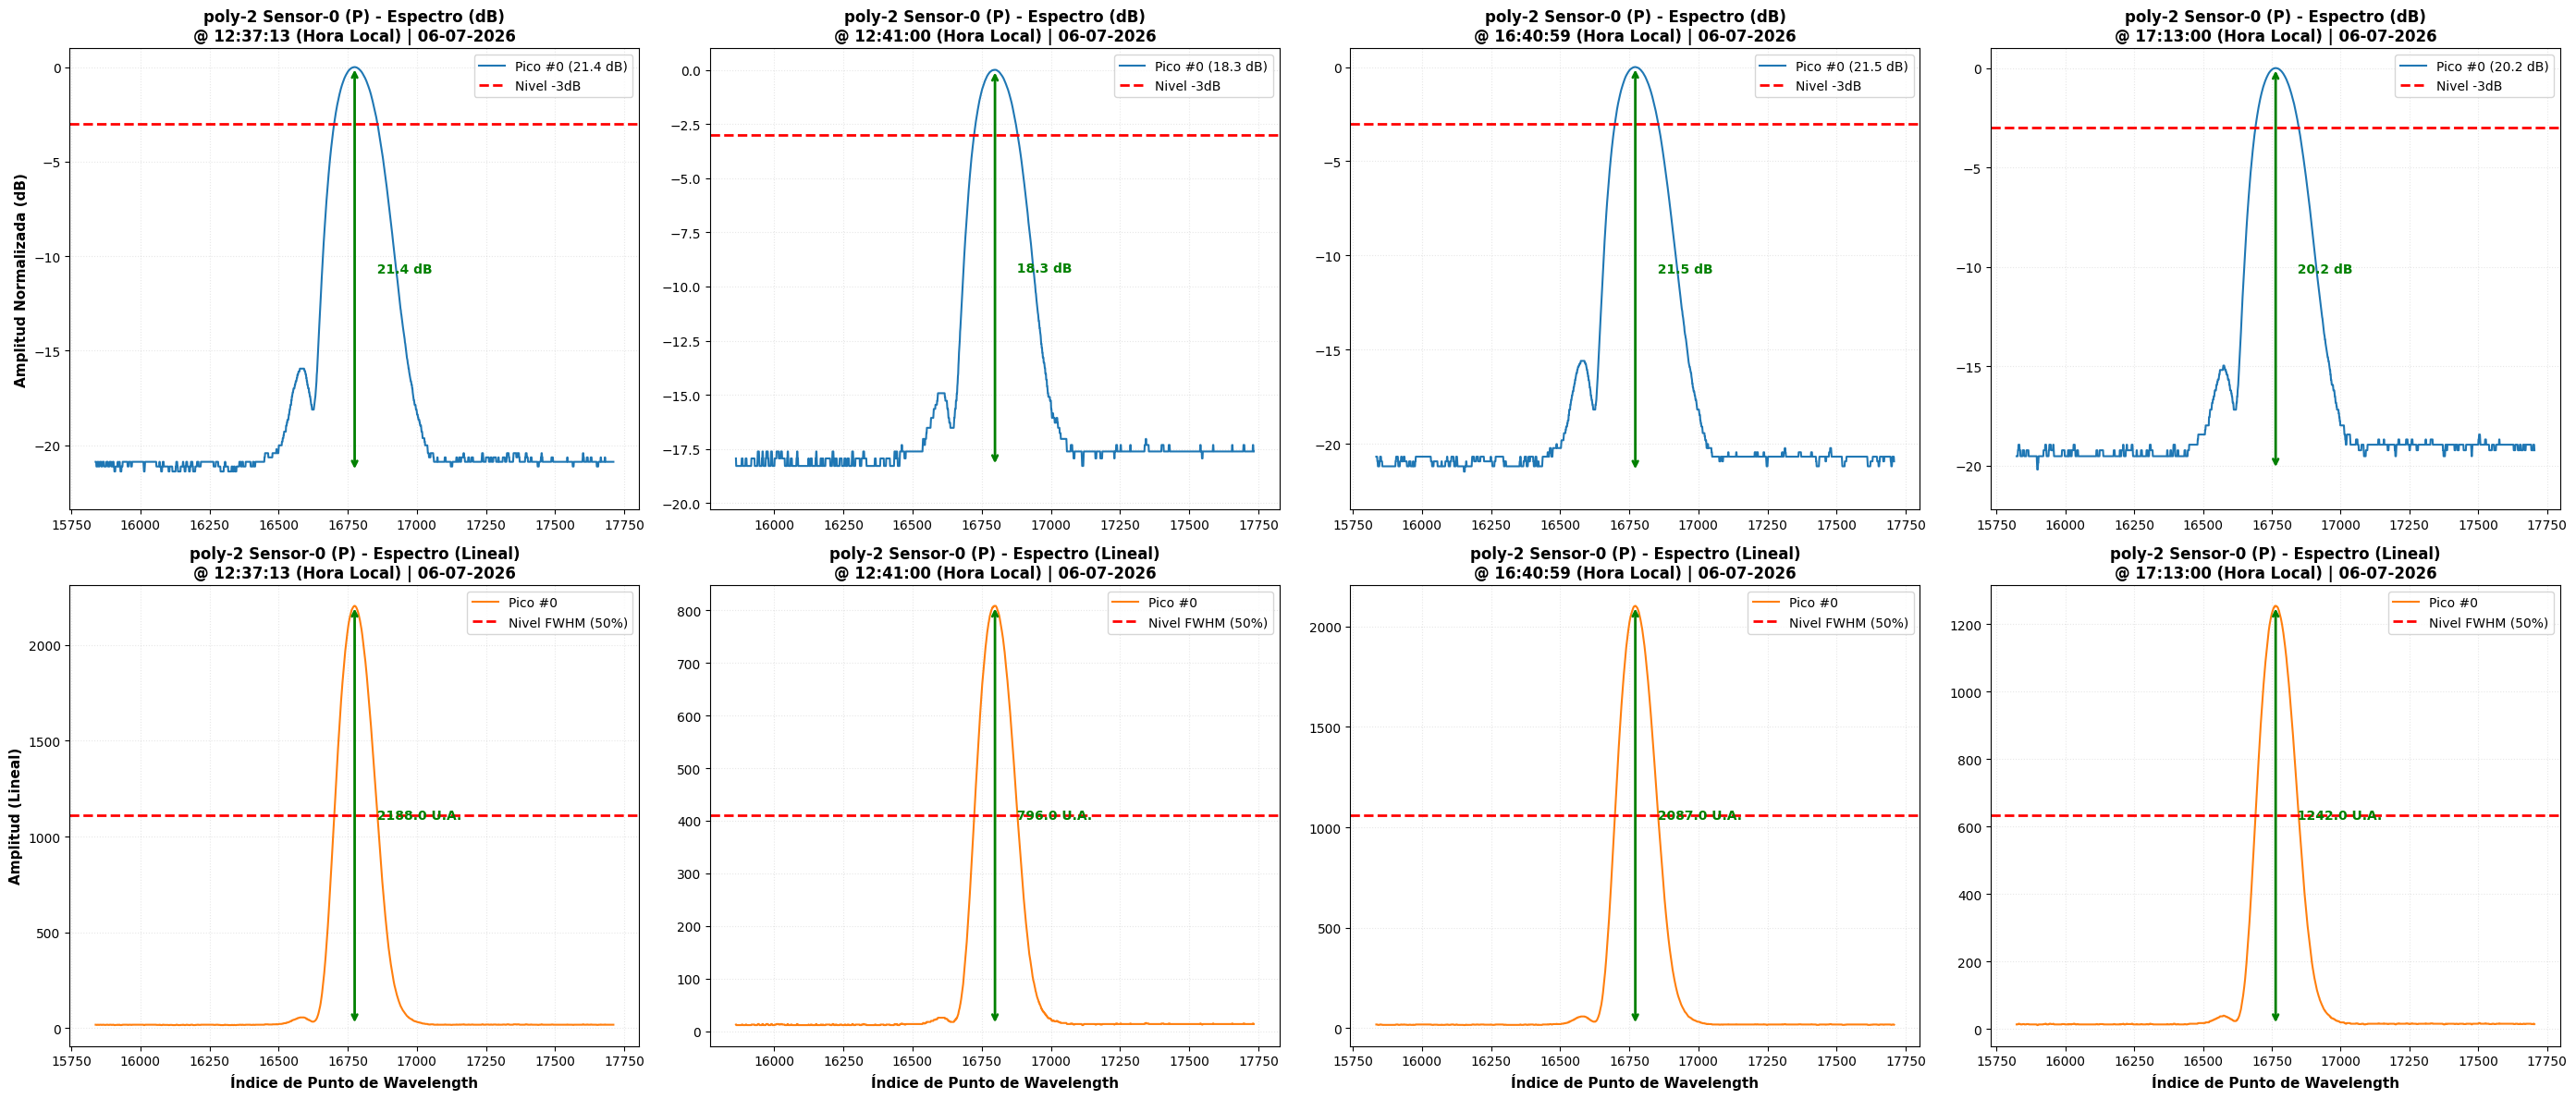

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS (4 TIEMPOS)
# ============================================================================

# ⏰ Tiempos a visualizar (Aplicando la regla de buscar 2h antes en el archivo)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 10, 37, 0),   # Nº 1: FC-FC (Hora real: ~12:37h)
    datetime.datetime(2026, 7, 6, 10, 41, 0),   # Nº 2: 1er Feedthrough (Hora real: 12:41h)
    datetime.datetime(2026, 7, 6, 14, 41, 0),   # Nº 3: 2º Feedthrough (Hora real: 16:41h)
    datetime.datetime(2026, 7, 6, 15, 13, 0)    # Nº 4: Prueba final de hoy (Hora real: 17:13h)
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

FIBER_NAME = f"poly-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO
# ============================================================================

def analyze_and_plot(file, target_time, ax_db, ax_lin):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO TIEMPO BUSCADO: {target_time.strftime('%H:%M:%S')} (UTC)")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        print(f"   Tiempo más cercano encontrado: {closest_time.strftime('%H:%M:%S')}")
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax_db.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        ax_lin.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        return

    # --- PASO 3: Análisis de datos (Cálculo robusto del fondo) ---
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        results_half = peak_widths(spectrum_full, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    window = max(int(fwhm_points * 6), 150) 
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    
    y_db = spectrum_db[start_idx:end_idx]
    y_lin = spectrum_full[start_idx:end_idx]
    
    # Cálculos Dinámica en dB
    base_level_db = np.min(y_db)
    peak_level_db = np.max(y_db) 
    amplitude_diff_db = peak_level_db - base_level_db
    
    # Cálculos Amplitud en Lineal
    base_level_lin = np.min(y_lin)
    peak_level_lin = np.max(y_lin)
    amplitude_diff_lin = peak_level_lin - base_level_lin
    fwhm_level_lin = base_level_lin + (amplitude_diff_lin * 0.5)

    print(f"   ✅ Pico en pos {center_idx} | Dinámica: {amplitude_diff_db:.2f} dB")

    # Calculamos la hora real (+2h) para el título
    real_time = closest_time + datetime.timedelta(hours=2)

    # --- PASO 4a: Dibujar en dB (Fila Superior) ---
    ax_db.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} ({amplitude_diff_db:.1f} dB)", color='#1f77b4')
    ax_db.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    ax_db.annotate('', xy=(center_idx, peak_level_db), xytext=(center_idx, base_level_db),
                   arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_db.text(center_idx + (window*0.05), (peak_level_db + base_level_db) / 2, f'  {amplitude_diff_db:.1f} dB', 
               color='green', fontweight='bold', va='center')
    
    if ax_db.get_subplotspec().colspan.start == 0:
        ax_db.set_ylabel("Amplitud Normalizada (dB)", fontsize=11, fontweight='bold')
        
    ax_db.set_title(f"{FIBER_NAME} - Espectro (dB)\n@ {real_time.strftime('%H:%M:%S')} (Hora Local) | 06-07-2026", fontsize=12, fontweight='bold')
    ax_db.legend(fontsize=10, loc='best')
    ax_db.grid(alpha=0.3, linestyle=':')
    ax_db.set_ylim(min(y_db) - 2, 1)

    # --- PASO 4b: Dibujar en Lineal (Fila Inferior) ---
    ax_lin.plot(x_pm, y_lin, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX}", color='#ff7f0e')
    ax_lin.axhline(fwhm_level_lin, color='red', linestyle='--', linewidth=2, label='Nivel FWHM (50%)')
    
    ax_lin.annotate('', xy=(center_idx, peak_level_lin), xytext=(center_idx, base_level_lin),
                    arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_lin.text(center_idx + (window*0.05), (peak_level_lin + base_level_lin) / 2, f'  {amplitude_diff_lin:.1f} U.A.', 
                color='green', fontweight='bold', va='center')
    
    ax_lin.set_xlabel("Índice de Punto de Wavelength", fontsize=11, fontweight='bold')
    
    if ax_lin.get_subplotspec().colspan.start == 0:
        ax_lin.set_ylabel("Amplitud (Lineal)", fontsize=11, fontweight='bold')
        
    ax_lin.set_title(f"{FIBER_NAME} - Espectro (Lineal)\n@ {real_time.strftime('%H:%M:%S')} (Hora Local) | 06-07-2026", fontsize=12, fontweight='bold')
    ax_lin.legend(fontsize=10, loc='best')
    ax_lin.grid(alpha=0.3, linestyle=':')

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR MATRIZ DE SUBPLOTS 2x4
# ============================================================================

# Crear figura extra ancha para alojar 4 columnas cómodamente
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            # Iterar sobre los 4 tiempos y asignar a las columnas correspondientes
            for col_idx, target_t in enumerate(TARGET_TIMES):
                analyze_and_plot(file, target_t, ax_db=axes[0, col_idx], ax_lin=axes[1, col_idx])
                
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

# Ajustar márgenes
plt.tight_layout()
plt.show()


🔍 PROCESANDO: Referencia (FC-FC) | Hora archivo: 10:37:00

🔍 PROCESANDO: Feedthrough 1 | Hora archivo: 10:41:00

🔍 PROCESANDO: Feedthrough 2 | Hora archivo: 14:41:00

🔍 PROCESANDO: Feedthrough 3 | Hora archivo: 15:13:00


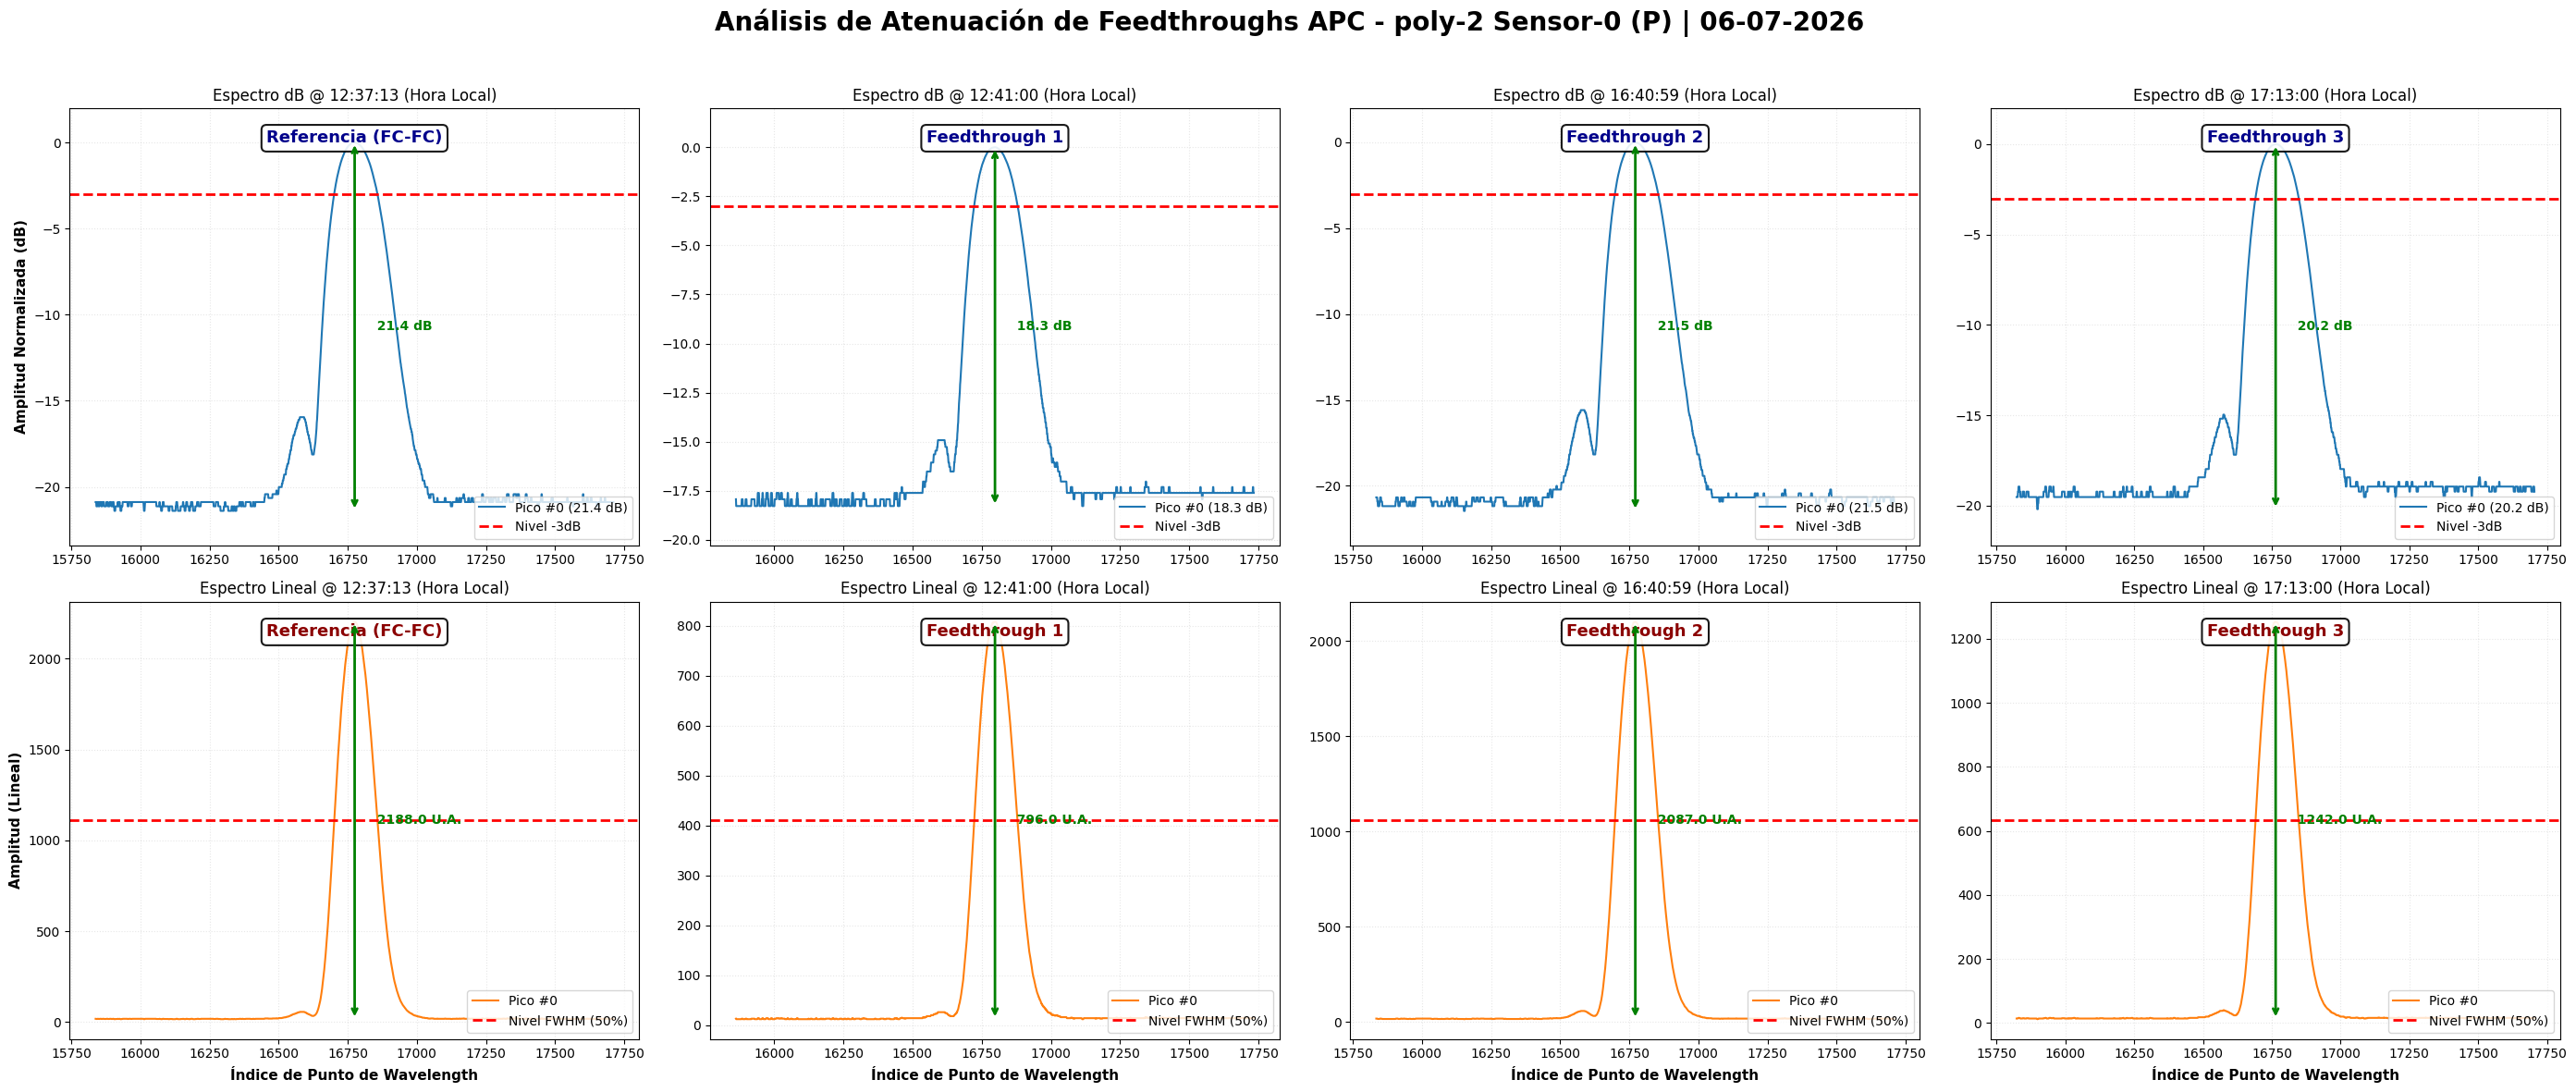

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import datetime
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTROS COMPARATIVOS (4 TIEMPOS)
# ============================================================================

# ⏰ Tiempos a visualizar (Aplicando la regla de buscar 2h antes en el archivo)
TARGET_TIMES = [
    datetime.datetime(2026, 7, 6, 10, 37, 0),   # Hora real: ~12:37h
    datetime.datetime(2026, 7, 6, 10, 41, 0),   # Hora real: 12:41h
    datetime.datetime(2026, 7, 6, 14, 41, 0),   # Hora real: 16:41h
    datetime.datetime(2026, 7, 6, 15, 13, 0)    # Hora real: 17:13h
]

# 🏷️ Etiquetas de configuración para cada columna
CONFIG_LABELS = [
    "Referencia (FC-FC)",
    "Feedthrough 1",
    "Feedthrough 2",
    "Feedthrough 3"
]

# ⚠️ ¡IMPORTANTE! Asegúrate de que la variable filepath esté definida
# filepath = "ruta_a_tu_archivo.root" 

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

FIBER_NAME = f"poly-2 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"

# ============================================================================
# FUNCIÓN DE ANÁLISIS Y PLOTEO
# ============================================================================

def analyze_and_plot(file, target_time, config_label, ax_db, ax_lin):
    print(f"\n" + "="*60)
    print(f"🔍 PROCESANDO: {config_label} | Hora archivo: {target_time.strftime('%H:%M:%S')}")
    print("="*60)
    
    # --- PASO 1: Buscar evento ---
    try:
        spectrum_tree = file['spectrum']
        try:
            timestamps_raw = spectrum_tree['t'].array(library="np")
        except:
            timestamps_raw = None
        
        if timestamps_raw is None or len(timestamps_raw) == 0:
            if 'peak' in file:
                timestamps_raw = file['peak']['t'].array(library="np")
            else:
                raise ValueError("No hay timestamps disponibles")
        
        if timestamps_raw.ndim == 2:
            timestamps = timestamps_raw[:, 0]
        else:
            timestamps = timestamps_raw.flatten()
        
        target_timestamp = target_time.timestamp()
        closest_idx_time = np.argmin(np.abs(timestamps - target_timestamp))
        closest_timestamp = timestamps[closest_idx_time]
        closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
        
        wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
        wav_data = wav_data_raw[0] if wav_data_raw.ndim in [3, 4] else wav_data_raw
        
    except Exception as e:
        print(f"   ❌ Error cargando evento: {e}")
        ax_db.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        ax_lin.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        return

    # --- PASO 2: Extraer espectro ---
    try:
        if wav_data.ndim == 3:
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
        elif wav_data.ndim == 2:
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            spectrum_full = wav_data[ch, :] if ch < wav_data.shape[0] else wav_data[PLOT_SENSOR_IDX, :]
        else:
            spectrum_full = wav_data
            
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        center_idx = all_peaks[PLOT_PEAK_IDX] if len(all_peaks) > PLOT_PEAK_IDX else (all_peaks[0] if len(all_peaks) > 0 else len(spectrum_full) // 2)
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        return

    # --- PASO 3: Análisis de datos ---
    spectrum_safe = np.where(spectrum_full <= 0, 1e-12, spectrum_full) 
    spectrum_db = 10 * np.log10(spectrum_safe / np.max(spectrum_safe))
    
    try:
        results_half = peak_widths(spectrum_full, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
    except:
        fwhm_points = 50
        
    window = max(int(fwhm_points * 6), 150) 
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum_db))
    
    x_pm = np.arange(start_idx, end_idx)
    
    y_db = spectrum_db[start_idx:end_idx]
    y_lin = spectrum_full[start_idx:end_idx]
    
    # Cálculos
    base_level_db = np.min(y_db)
    peak_level_db = np.max(y_db) 
    amplitude_diff_db = peak_level_db - base_level_db
    
    base_level_lin = np.min(y_lin)
    peak_level_lin = np.max(y_lin)
    amplitude_diff_lin = peak_level_lin - base_level_lin
    fwhm_level_lin = base_level_lin + (amplitude_diff_lin * 0.5)

    real_time = closest_time + datetime.timedelta(hours=2)

    # Estilo de la caja de texto para las etiquetas
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.9)

    # --- PASO 4a: Dibujar en dB (Fila Superior) ---
    ax_db.plot(x_pm, y_db, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} ({amplitude_diff_db:.1f} dB)", color='#1f77b4')
    ax_db.axhline(-3, color='red', linestyle='--', linewidth=2, label='Nivel -3dB')
    
    # Etiqueta de Configuración visual
    ax_db.text(0.5, 0.95, config_label, transform=ax_db.transAxes, ha='center', va='top', 
               fontsize=13, fontweight='bold', color='darkblue', bbox=bbox_props)
    
    ax_db.annotate('', xy=(center_idx, peak_level_db), xytext=(center_idx, base_level_db),
                   arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_db.text(center_idx + (window*0.05), (peak_level_db + base_level_db) / 2, f'  {amplitude_diff_db:.1f} dB', 
               color='green', fontweight='bold', va='center')
    
    if ax_db.get_subplotspec().colspan.start == 0:
        ax_db.set_ylabel("Amplitud Normalizada (dB)", fontsize=11, fontweight='bold')
        
    ax_db.set_title(f"Espectro dB @ {real_time.strftime('%H:%M:%S')} (Hora Local)", fontsize=12)
    ax_db.legend(fontsize=10, loc='lower right')
    ax_db.grid(alpha=0.3, linestyle=':')
    ax_db.set_ylim(min(y_db) - 2, 2)

    # --- PASO 4b: Dibujar en Lineal (Fila Inferior) ---
    ax_lin.plot(x_pm, y_lin, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX}", color='#ff7f0e')
    ax_lin.axhline(fwhm_level_lin, color='red', linestyle='--', linewidth=2, label='Nivel FWHM (50%)')
    
    # Etiqueta de Configuración visual
    ax_lin.text(0.5, 0.95, config_label, transform=ax_lin.transAxes, ha='center', va='top', 
                fontsize=13, fontweight='bold', color='darkred', bbox=bbox_props)
    
    ax_lin.annotate('', xy=(center_idx, peak_level_lin), xytext=(center_idx, base_level_lin),
                    arrowprops=dict(arrowstyle='<->', color='green', linewidth=2))
    ax_lin.text(center_idx + (window*0.05), (peak_level_lin + base_level_lin) / 2, f'  {amplitude_diff_lin:.1f} U.A.', 
                color='green', fontweight='bold', va='center')
    
    ax_lin.set_xlabel("Índice de Punto de Wavelength", fontsize=11, fontweight='bold')
    
    if ax_lin.get_subplotspec().colspan.start == 0:
        ax_lin.set_ylabel("Amplitud (Lineal)", fontsize=11, fontweight='bold')
        
    ax_lin.set_title(f"Espectro Lineal @ {real_time.strftime('%H:%M:%S')} (Hora Local)", fontsize=12)
    ax_lin.legend(fontsize=10, loc='lower right')
    ax_lin.grid(alpha=0.3, linestyle=':')

# ============================================================================
# EJECUCIÓN PRINCIPAL: CREAR MATRIZ DE SUBPLOTS 2x4
# ============================================================================

fig, axes = plt.subplots(2, 4, figsize=(28, 12))

# Título general de toda la figura
fig.suptitle(f"Análisis de Atenuación de Feedthroughs APC - {FIBER_NAME} | 06-07-2026", 
             fontsize=20, fontweight='bold', y=0.98)

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            for col_idx, (target_t, label) in enumerate(zip(TARGET_TIMES, CONFIG_LABELS)):
                analyze_and_plot(file, target_t, label, ax_db=axes[0, col_idx], ax_lin=axes[1, col_idx])
                
except Exception as e:
    print(f"\n❌ Error abriendo el archivo ROOT: {e}")

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Deja espacio para el super-título
plt.show()